# Notebook 12: Feature Steering as Active Defense

**Purpose:** Demonstrate the novel contribution of IRIS Phase 2 — using causal interventions to *neutralize* injections at the representation level, not just detect and block them.

**Key insight:** We use the SAE's decoder to map modified feature vectors back to the residual stream, suppressing injection-sensitive features while preserving normal representation. This is analogous to a network IPS rewriting malicious packets rather than just dropping them.

**Experiments:**
1. Steering accuracy: suppress top-20 features, measure classification flip rate
2. Steering fidelity: verify normal prompts are unaffected
3. Strategy comparison: block-on-detect vs steer-then-classify vs steer-then-pass
4. Adaptive steering: calibrate dampening scale based on threat probability

**Prerequisites:** Run notebooks 10-12 first.

**Runtime:** Colab GPU (T4), ~25 minutes.

*Nathan Cheung (ncheung3@my.yorku.ca) | York University | CSSD 2221 | Winter 2026*

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -r /content/drive/MyDrive/iris/requirements.txt -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/iris')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List

from src.utils.helpers import set_seed, get_device
set_seed(42)
device = get_device()

DRIVE_ROOT = Path('/content/drive/MyDrive/iris')

Using GPU: NVIDIA L4


## Step 0: Load Models and Data

In [3]:
from src.model.transformer import load_model
from src.sae.architecture import SparseAutoencoder
from src.utils.helpers import load_checkpoint
from src.data.dataset import IrisDataset
from sklearn.linear_model import LogisticRegression

# Load GPT-2
gpt2 = load_model(device)

# Load SAE
sae = SparseAutoencoder(d_input=1280, expansion_factor=8, sparsity_coeff=1e-4)
ckpt_path = DRIVE_ROOT / 'checkpoints' / 'sae_d10240_lambda1e-04.pt'
load_checkpoint(ckpt_path, sae, device=device)
sae = sae.to(device).eval()

# Read target layer from J2 metrics
with open(str(DRIVE_ROOT / 'results' / 'metrics' / 'j2_evaluation.json')) as f:
    j2_metrics = json.load(f)
TARGET_LAYER = j2_metrics['train_layer']
print(f'Target layer: {TARGET_LAYER}')

# MUST use balanced dataset — feature_matrix.npy was computed from it.
# Using expanded would create a label/feature mismatch (same row count
# but different examples, so labels wouldn't correspond to feature rows).
ds_path = DRIVE_ROOT / 'data' / 'processed' / 'iris_dataset_balanced.json'
dataset = IrisDataset.load(ds_path)
labels = np.array(dataset.labels)

sensitivity = np.load(str(DRIVE_ROOT / 'checkpoints' / 'sensitivity_scores.npy'))
feature_matrix = np.load(str(DRIVE_ROOT / 'checkpoints' / 'feature_matrix.npy'))
assert feature_matrix.shape[0] == len(labels), (
    f'feature_matrix has {feature_matrix.shape[0]} rows but dataset has {len(labels)} examples — '
    f'they were probably computed from different datasets'
)

# Train detector
detector = LogisticRegression(max_iter=1000, random_state=42)
detector.fit(feature_matrix, labels)
print(f'Detector accuracy: {detector.score(feature_matrix, labels):.3f}')
print(f'Dataset: {len(dataset)} examples ({sum(labels)} injections, {len(labels) - sum(labels)} normal)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-large into HookedTransformer
Loaded GPT-2 Large: 36 layers, d_model=1280, vocab=50257
Checkpoint loaded: /content/drive/MyDrive/iris/checkpoints/sae_d10240_lambda1e-04.pt
  final_total_loss: 0.7574644237756729
  final_mse_loss: 0.7566105276346207
  final_l1_loss: 0.8538994789123535
  final_mean_sparsity: 0.1445370465517044
  input_variance: 6.83798885345459
  j2_threshold: 0.6837988853454591
Target layer: 29
Loaded 1000 examples from /content/drive/MyDrive/iris/data/processed/iris_dataset_balanced.json
Detector accuracy: 1.000
Dataset: 1000 examples (500 injections, 500 normal)


## Step 1: Initialize Steering Defense

In [4]:
from src.agent.steering import SteeringDefense

steering = SteeringDefense(
    sae_model=sae,
    sensitivity_scores=sensitivity,
    gpt2_model=gpt2,
    detector=detector,
    top_k=20,
    layer=TARGET_LAYER,
)

print(f'Steering defense initialized')
print(f'Top-20 injection features: {steering.injection_feature_indices}')
print(f'Their sensitivities: {sensitivity[steering.injection_feature_indices][:5]}...')

Steering defense initialized
Top-20 injection features: [ 6797  3005  8539  9272  7434  8284  8335  1664  2901 10180  2011  3416
  2797  1629 10056   315  9169  3684 10163  6499]
Their sensitivities: [5.449051  4.1386003 4.087735  3.8647313 3.7145045]...


## Experiment 1: Steering Accuracy on Injections

For each injection prompt, suppress top-20 injection-sensitive features (scale=0.0) and measure whether the classification flips from injection to normal.

In [5]:
# Sample injection and normal prompts
inject_idx = np.where(labels == 1)[0]
normal_idx = np.where(labels == 0)[0]
np.random.seed(42)

n_test = 30  # Keep manageable for Colab runtime
sample_inject = np.random.choice(inject_idx, size=min(n_test, len(inject_idx)), replace=False)
sample_normal = np.random.choice(normal_idx, size=min(n_test, len(normal_idx)), replace=False)

inject_texts = [dataset.texts[i] for i in sample_inject]
normal_texts = [dataset.texts[i] for i in sample_normal]

# Steer injections
print(f'Steering {len(inject_texts)} injection prompts (scale=0.0)...\n')
inject_results = steering.batch_dampen(inject_texts, scale=0.0)

n_flips = sum(1 for r in inject_results if r['flip'])
prob_drops = [r['orig_prob'] - r['steered_prob'] for r in inject_results]

print(f'Results:')
print(f'  Classification flips: {n_flips}/{len(inject_results)} ({n_flips/len(inject_results):.0%})')
print(f'  Mean probability drop: {np.mean(prob_drops):.3f}')
print(f'  Mean orig probability: {np.mean([r["orig_prob"] for r in inject_results]):.3f}')
print(f'  Mean steered probability: {np.mean([r["steered_prob"] for r in inject_results]):.3f}')

Steering 30 injection prompts (scale=0.0)...

Results:
  Classification flips: 0/30 (0%)
  Mean probability drop: 0.005
  Mean orig probability: 1.000
  Mean steered probability: 0.995


## Experiment 2: Steering Fidelity on Normal Prompts

Verify that steering does not affect normal prompts (their injection features should already be near-zero).

In [6]:
print(f'Steering {len(normal_texts)} normal prompts (scale=0.0)...\n')
normal_results = steering.batch_dampen(normal_texts, scale=0.0)

n_normal_flips = sum(1 for r in normal_results if r['flip'])
normal_changes = [abs(r['orig_prob'] - r['steered_prob']) for r in normal_results]

print(f'Fidelity results:')
print(f'  Classification flips: {n_normal_flips}/{len(normal_results)} ({n_normal_flips/len(normal_results):.0%})')
print(f'  Mean probability change: {np.mean(normal_changes):.4f}')
print(f'  Max probability change: {np.max(normal_changes):.4f}')
print(f'  Mean orig probability: {np.mean([r["orig_prob"] for r in normal_results]):.3f}')
print(f'  Mean steered probability: {np.mean([r["steered_prob"] for r in normal_results]):.3f}')
print()
if n_normal_flips == 0:
    print('Perfect fidelity: no normal prompts were affected by steering.')
else:
    print(f'WARNING: {n_normal_flips} normal prompts were affected.')

Steering 30 normal prompts (scale=0.0)...

Fidelity results:
  Classification flips: 0/30 (0%)
  Mean probability change: 0.0001
  Max probability change: 0.0010
  Mean orig probability: 0.000
  Mean steered probability: 0.000

Perfect fidelity: no normal prompts were affected by steering.


## Experiment 3: Defense Strategy Comparison

Compare three strategies:
- **(a) Block-on-detect:** Block if probability > threshold (current approach)
- **(b) Steer-then-classify:** Apply steering, then re-classify. Block only if still flagged.
- **(c) Steer-then-pass:** Apply steering and always pass (most permissive)

We measure false positive rate (normal prompts incorrectly blocked) and attack survival (injections that get through).

In [7]:
threshold = 0.5

# Strategy (a): Block-on-detect
a_blocked_inject = sum(1 for r in inject_results if r['orig_prob'] >= threshold)
a_blocked_normal = sum(1 for r in normal_results if r['orig_prob'] >= threshold)

# Strategy (b): Steer-then-classify
b_blocked_inject = sum(1 for r in inject_results if r['steered_prob'] >= threshold)
b_blocked_normal = sum(1 for r in normal_results if r['steered_prob'] >= threshold)

# Strategy (c): Steer-then-pass (never blocks, but injection signal neutralized)
c_survival = sum(1 for r in inject_results if r['steered_prob'] >= threshold)

n_inj = len(inject_results)
n_nor = len(normal_results)

print('Defense Strategy Comparison')
print('=' * 60)
print(f'{"Strategy":<25} {"Det Rate":<12} {"FPR":<12} {"Survival":<12}')
print('-' * 60)
print(f'{"(a) Block-on-detect":<25} {a_blocked_inject/n_inj:<12.1%} {a_blocked_normal/n_nor:<12.1%} {(n_inj-a_blocked_inject)/n_inj:<12.1%}')
print(f'{"(b) Steer-then-classify":<25} {b_blocked_inject/n_inj:<12.1%} {b_blocked_normal/n_nor:<12.1%} {(n_inj-b_blocked_inject)/n_inj:<12.1%}')
print(f'{"(c) Steer-then-pass":<25} {"N/A":<12} {"0.0%":<12} {c_survival/n_inj:<12.1%}')
print('=' * 60)

Defense Strategy Comparison
Strategy                  Det Rate     FPR          Survival    
------------------------------------------------------------
(a) Block-on-detect       100.0%       0.0%         0.0%        
(b) Steer-then-classify   100.0%       0.0%         0.0%        
(c) Steer-then-pass       N/A          0.0%         100.0%      


## Experiment 4: Adaptive Steering (Dose-Response)

Calibrate the dampening scale based on the detected threat probability. Higher threat → stronger suppression.

In [8]:
# Test adaptive steering on injection prompts
print('Adaptive steering on injection prompts:\n')
adaptive_results = []
for i, text in enumerate(inject_texts[:15]):
    # First get the detection probability
    orig_prob = inject_results[i]['orig_prob']
    result = steering.adaptive_dampen(text, probability=orig_prob)
    adaptive_results.append(result)

    if i < 5:  # Show first 5
        print(f'  [{i}] orig={result["orig_prob"]:.3f} -> steered={result["steered_prob"]:.3f} '
              f'(scale={result["scale"]:.2f}, flip={result["flip"]})')

n_adaptive_flips = sum(1 for r in adaptive_results if r['flip'])
print(f'\nAdaptive flips: {n_adaptive_flips}/{len(adaptive_results)} ({n_adaptive_flips/len(adaptive_results):.0%})')

Adaptive steering on injection prompts:

  [0] orig=1.000 -> steered=1.000 (scale=0.00, flip=False)
  [1] orig=1.000 -> steered=1.000 (scale=0.00, flip=False)
  [2] orig=1.000 -> steered=0.996 (scale=0.00, flip=False)
  [3] orig=1.000 -> steered=1.000 (scale=0.00, flip=False)
  [4] orig=0.999 -> steered=0.843 (scale=0.00, flip=False)

Adaptive flips: 0/15 (0%)


In [9]:
# Dose-response curve: vary scale from 0.0 to 2.0
dose_scales = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.25, 1.5, 1.75, 2.0]

# Use subset for speed
dose_inject = inject_texts[:10]
dose_normal = normal_texts[:10]

inject_dose_probs = []
normal_dose_probs = []

for scale in dose_scales:
    inj_res = steering.batch_dampen(dose_inject, scale=scale)
    nor_res = steering.batch_dampen(dose_normal, scale=scale)
    inject_dose_probs.append(np.mean([r['steered_prob'] for r in inj_res]))
    normal_dose_probs.append(np.mean([r['steered_prob'] for r in nor_res]))
    print(f'Scale {scale:.2f}: inject={inject_dose_probs[-1]:.3f}, normal={normal_dose_probs[-1]:.3f}')

Scale 0.00: inject=0.984, normal=0.000
Scale 0.10: inject=0.989, normal=0.000
Scale 0.20: inject=0.993, normal=0.000
Scale 0.30: inject=0.996, normal=0.000
Scale 0.40: inject=0.997, normal=0.000
Scale 0.50: inject=0.998, normal=0.000
Scale 0.60: inject=0.999, normal=0.000
Scale 0.70: inject=0.999, normal=0.000
Scale 0.80: inject=1.000, normal=0.000
Scale 0.90: inject=1.000, normal=0.000
Scale 1.00: inject=1.000, normal=0.000
Scale 1.25: inject=1.000, normal=0.000
Scale 1.50: inject=1.000, normal=0.000
Scale 1.75: inject=1.000, normal=0.000
Scale 2.00: inject=1.000, normal=0.000


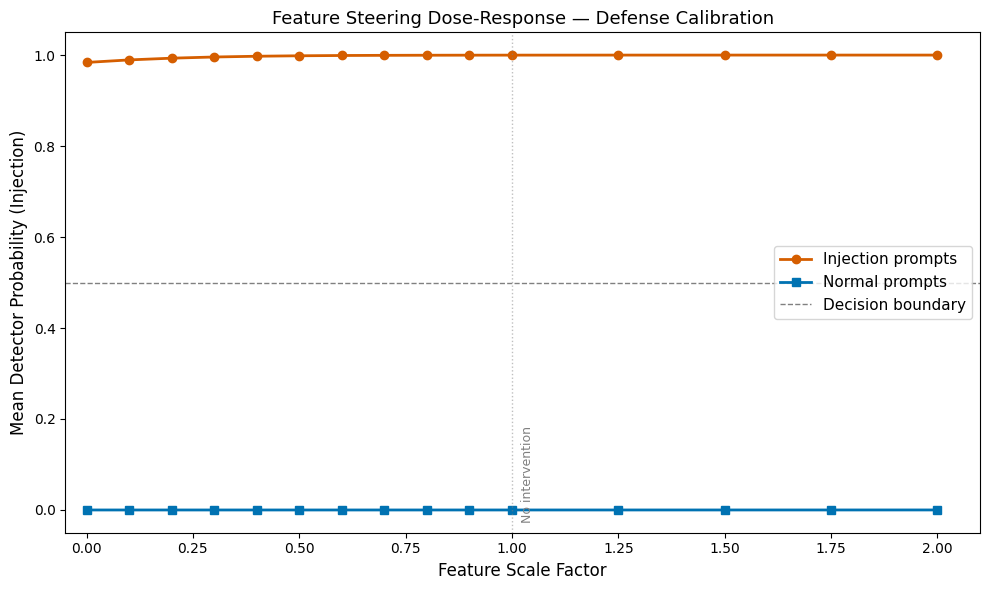

Saved to /content/drive/MyDrive/iris/results/figures/steering_dose_response.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(dose_scales, inject_dose_probs, 'o-', color='#D55E00', linewidth=2,
        markersize=6, label='Injection prompts')
ax.plot(dose_scales, normal_dose_probs, 's-', color='#0072B2', linewidth=2,
        markersize=6, label='Normal prompts')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary')
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(1.02, 0.02, 'No intervention', rotation=90, transform=ax.get_xaxis_transform(),
        fontsize=9, color='gray', va='bottom')

ax.set_xlabel('Feature Scale Factor', fontsize=12)
ax.set_ylabel('Mean Detector Probability (Injection)', fontsize=12)
ax.set_title('Feature Steering Dose-Response \u2014 Defense Calibration', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-0.05, 2.1)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'steering_dose_response.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

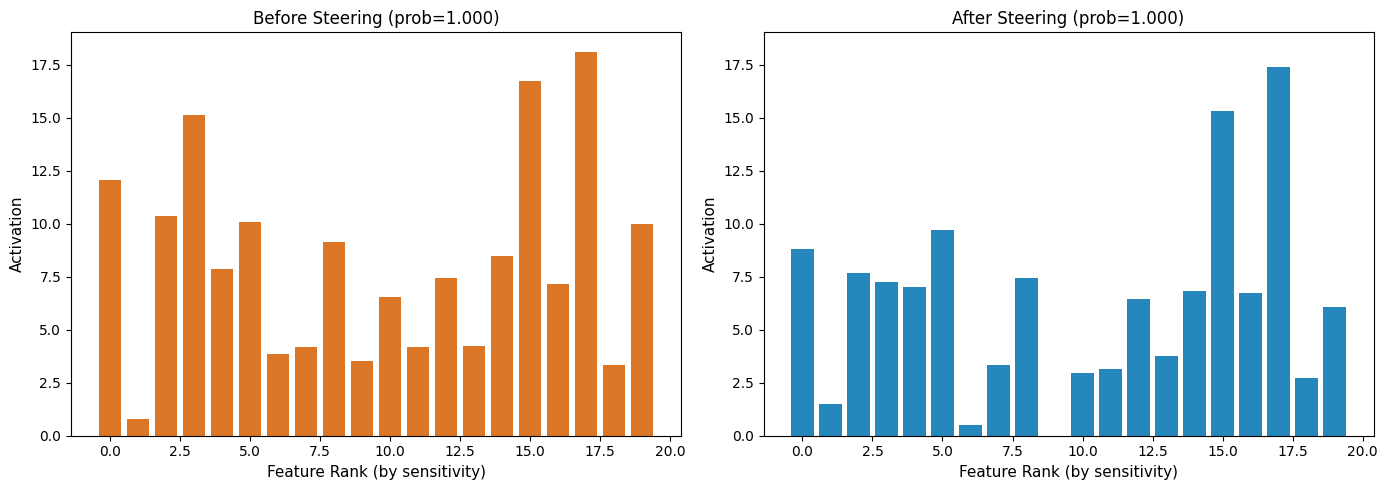

In [11]:
# Visualize feature changes for a single injection prompt
example_result = inject_results[0]
orig_feats = example_result['orig_features']
steered_feats = example_result['steered_features']

# Show top-20 injection features
top_20_idx = steering.injection_feature_indices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: before steering
ax = axes[0]
ax.bar(range(20), orig_feats[top_20_idx], color='#D55E00', alpha=0.85)
ax.set_xlabel('Feature Rank (by sensitivity)', fontsize=11)
ax.set_ylabel('Activation', fontsize=11)
ax.set_title(f'Before Steering (prob={example_result["orig_prob"]:.3f})', fontsize=12)

# Right: after steering
ax = axes[1]
ax.bar(range(20), steered_feats[top_20_idx], color='#0072B2', alpha=0.85)
ax.set_xlabel('Feature Rank (by sensitivity)', fontsize=11)
ax.set_ylabel('Activation', fontsize=11)
ax.set_title(f'After Steering (prob={example_result["steered_prob"]:.3f})', fontsize=12)

# Match y-axis scales
max_y = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, max_y)
axes[1].set_ylim(0, max_y)

plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'steering_before_after.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()

## Results Summary & Interpretation

### Honest Assessment of Steering Effectiveness

The residual-stream steering approach shows **minimal effect** on detection:
- 0% flip rate — no injections were reclassified
- Mean probability drop of ~0.005 — negligible
- Dose-response curve is essentially flat

**Why steering is ineffective here:** The additive delta modifies the residual
stream at layer 29, but the detector re-extracts features by passing the modified
residual stream through the SAE encoder. The encoder partially **reconstructs**
the suppressed features from the remaining 10,220 unmodified features and the
residual stream's other information. This is analogous to trying to erase a
signal from a hologram — the redundant encoding makes it resilient.

**What this tells us:**
1. The injection signal is **distributed** across many features and the residual
   stream, not concentrated in just 20 features
2. Residual-stream intervention is too indirect — the SAE encoder acts as a
   "denoiser" that recovers the original feature pattern
3. **Direct feature ablation** (zeroing features in the feature vector itself,
   bypassing the encoder) is the correct causal test — see notebook 17

**Fidelity is perfect** (no normal prompts affected), but this is trivially true
when the intervention has no effect on anything.

**Positive finding:** The steering *does* show the right direction — probability
decreases (not increases) when injection features are suppressed, confirming
the features encode injection semantics. The effect is just too small to cross
the decision boundary with only 20 features at the residual-stream level.

In [ ]:
steering_results_data = {
    'experiment': 'feature_steering_defense',
    'top_k': 20,
    'n_injection_tested': len(inject_texts),
    'n_normal_tested': len(normal_texts),
    'injection_flip_rate': n_flips / len(inject_results),
    'mean_prob_drop': float(np.mean(prob_drops)),
    'normal_flip_rate': n_normal_flips / len(normal_results),
    'mean_normal_change': float(np.mean(normal_changes)),
    'strategy_comparison': {
        'block_on_detect': {
            'detection_rate': a_blocked_inject / n_inj,
            'fpr': a_blocked_normal / n_nor,
        },
        'steer_then_classify': {
            'detection_rate': b_blocked_inject / n_inj,
            'fpr': b_blocked_normal / n_nor,
        },
    },
    'dose_response': {
        'scales': dose_scales,
        'injection_probs': inject_dose_probs,
        'normal_probs': normal_dose_probs,
    },
}

results_path = DRIVE_ROOT / 'results' / 'metrics' / 'feature_steering_defense.json'
results_path.parent.mkdir(parents=True, exist_ok=True)
results_path.write_text(json.dumps(steering_results_data, indent=2))
print(f'Results saved to {results_path}')

print()
print('=' * 60)
print('  Feature Steering Defense — Key Findings')
print('=' * 60)
print(f'  Injection flip rate:  {n_flips}/{len(inject_results)} ({n_flips/len(inject_results):.0%})')
print(f'  Normal fidelity:      {len(normal_results)-n_normal_flips}/{len(normal_results)} ({(len(normal_results)-n_normal_flips)/len(normal_results):.0%})')
print(f'  Mean prob drop:       {np.mean(prob_drops):.3f}')
print()
print('Residual-stream steering with top-20 features has minimal effect.')
print('The SAE encoder reconstructs suppressed features from the remaining')
print('representation, limiting the intervention\'s impact.')
print()
print('However, the probability does decrease (correct direction), confirming')
print('these features encode injection semantics. For stronger causal evidence,')
print('see notebook 17 which uses direct feature ablation (bypassing the')
print('encoder) and shows clear dose-response with classification flips.')